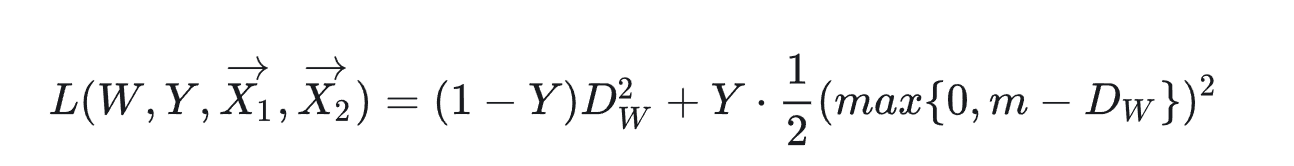
---

### 1. 参数含义
* $L$：总损失（系统的总能量）。
* $Y$：标签。注意这里的定义：通常 $Y=0$ 表示两个样本**相似**（正样本对），$Y=1$ 表示两个样本**不相似**（负样本对）。
* $D_W$：两个样本特征向量之间的距离（比如欧氏距离）。
* $m$：**Margin（边际距离）**。这是一个关键常数，决定了“推力弹簧”在什么距离下失效。

---

### 2. 公式拆解：拉与推的平衡

这个公式本质上是一个 **“开关”函数**，通过 $Y$ 来控制哪一部分弹簧起作用。

#### 左半部分：$(1 - Y)D_W^2$ —— 拉力弹簧
* **触发条件：** 当 $Y=0$（样本相似）时，这部分生效。
* **物理意义：** 这是一个**拉力弹簧**。如果两个本该相似的样本距离 $D_W$ 很大，损失 $L$ 就会随着距离的平方迅速增加。
* **目标：** 为了让 $L$ 减小，模型必须把这两个点**拉近**，直到距离为 0。

#### 右半部分：$Y \cdot \frac{1}{2}(\max\{0, m - D_W\})^2$ —— 推力弹簧
* **触发条件：** 当 $Y=1$（样本不相似）时，这部分生效。
* **物理意义：** 这是一个**带限位的推力弹簧**。
    * 如果 $D_W < m$：说明两个不相关的样本靠得太近了，弹簧被压缩，产生损失，要把它们**推开**。
    * 如果 $D_W \ge m$：说明两个样本已经离得足够远了（超过了安全距离 $m$），弹簧完全松开，$\max$ 函数输出 0，损失为 0。
* **目标：** 模型只需要把不相似的样本推开到 $m$ 远就行了，没必要推到无穷远。


---

### 3. 为什么这个公式能体现弹簧直觉？

你可以把 $D_W$ 想象成弹簧的当前长度：

1.  **对于正样本：** 弹簧的“自然长度”是 0。只要有长度，就有回复力。
2.  **对于负样本：** 弹簧的“自然长度”是 $m$。只要长度小于 $m$，弹簧就会产生向外的推力。

### 4. 总结

这个公式就是通过数学手段，给模型下了两道指令：
1.  **若是同类，请贴贴（距离趋于 0）。**
2.  **若是异类，请保持社交距离（距离大于 $m$）。**

# 视觉对比学习 (Contrastive Learning) 核心笔记：SimCLR 与 MoCo

**核心目标：** 在无标签的情况下，通过最大化同一图像的不同增强视图之间的一致性，让神经网络学会提取具有强大泛化能力的表征（Representation）。这种无监督预训练的底座，能为后续的检测、分割（如复杂背景下的目标识别）以及模型量化部署提供极其鲁棒的特征空间。

---
## 1. 核心直觉：物理学的“弹簧模型”与对比损失

对比学习的本质可以具象化为一个质点弹簧系统：
* **拉力弹簧 (Attract)：** 互为正样本（同一实例的不同增强视图）的特征向量之间存在拉力，促使它们在特征空间中靠近，距离趋于 0。
* **推力弹簧 (Repel)：** 互为负样本（不同实例）的特征向量之间存在推力，迫使它们相互远离，直到超过安全边际（Margin）。

**基础对比损失公式 (Contrastive Loss)：**
$$L(W, Y, \vec{X_1}, \vec{X_2}) = (1 - Y)D_W^2 + Y \cdot \frac{1}{2}(\max\{0, m - D_W\})^2$$
其中，$Y=0$ 表示正样本对（仅保留拉力项），$Y=1$ 表示负样本对（仅保留推力项），$m$ 为推力失效的边界距离。

---

## 2. SimCLR 框架的四大核心组件

SimCLR 证明了无需特殊的网络架构或内存库，只需极简的端到端框架即可实现 SOTA 的自监督效果。

1.  **随机数据增强 (Stochastic Data Augmentation)：**
    * 对输入图像 $x$ 进行两次不同的随机增强，生成正样本对 $\tilde{x}_i$ 和 $\tilde{x}_j$。
    * **关键结论：** **随机裁剪（Crop）+ 随机颜色失真（Color Distortion）** 是最强组合。颜色失真能防止模型利用局部颜色直方图“走捷径”，迫使其学习形状和纹理特征。
2.  **基础编码器 (Base Encoder, $f(\cdot)$)：**
    * 通常使用 ResNet（如 ResNet-50）提取特征表示 $h_i = f(\tilde{x}_i)$。
3.  **非线性投影头 (Non-linear Projection Head, $g(\cdot)$)：**
    * 一个包含隐藏层和 ReLU 激活函数的两层 MLP：$z_i = g(h_i) = W^{(2)}\sigma(W^{(1)}h_i)$。
    * **关键作用：** 保护 $h_i$ 层的特征不被对比损失破坏。对比任务要求特征对颜色、方向等变换保持“不变性”，而在投影头空间 $z_i$ 中计算损失，可以作为“缓冲”，使得 $h_i$ 依然能保留用于下游任务的丰富语义。
4.  **NT-Xent 损失函数 (Normalized Temperature-scaled Cross Entropy)：**
    * 在投影空间 $z$ 中计算，利用余弦相似度和温度参数 $\tau$ 对样本难度进行加权。

---

## 3. NT-Xent 损失函数深度解析

对于大小为 $N$ 的 Batch，经过增强后得到 $2N$ 个样本。对于任意样本 $i$，在剩下的 $2N-1$ 个样本中找寻其唯一的正样本 $j$。

$$l_{i,j} = -\log \frac{\exp(\text{sim}(z_i, z_j)/\tau)}{\sum_{k=1}^{2N} \mathbb{1}_{[k \neq i]} \exp(\text{sim}(z_i, z_k)/\tau)}$$

* $\text{sim}(z_i, z_j)$：$l_2$ 归一化后的点积（即余弦相似度）。
* $\tau$ **(Temperature)：** 温度参数。较小的 $\tau$ 会放大“困难负样本”（Hard Negatives，即长得像但实际是异类的样本）产生的梯度，强迫模型更精细地划分特征空间。

---


```python
import torch
import torch.nn as nn
import torch.nn.functional as F

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super(NTXentLoss, self).__init__()
        self.temperature = temperature

    def forward(self, z_i, z_j):
        """
        z_i: 视图1的特征向量 [batch_size, feature_dim]
        z_j: 视图2的特征向量 [batch_size, feature_dim]
        """
        batch_size = z_i.shape[0]
        
        # 1. 拼接所有特征 [2*batch_size, feature_dim] 并进行 L2 归一化
        z = torch.cat([z_i, z_j], dim=0)
        z = F.normalize(z, p=2, dim=1)
        
        # 2. 计算相似度矩阵 [2*batch_size, 2*batch_size]
        sim_matrix = torch.matmul(z, z.T) / self.temperature
        
        # 3. 构建标签 (正样本的索引)
        # 对于 z_i 的正样本是 z_j (索引偏移 batch_size)
        # 对于 z_j 的正样本是 z_i (索引偏移 -batch_size)
        labels = torch.cat([torch.arange(batch_size) + batch_size, 
                            torch.arange(batch_size)], dim=0).to(z.device)
        
        # 4. 掩码操作：把对角线元素（自己与自己的相似度）设为极小值，排除在外
        mask = torch.eye(2 * batch_size, dtype=torch.bool).to(z.device)
        sim_matrix.masked_fill_(mask, -1e9)
        
        # 5. 计算交叉熵损失
        loss = F.cross_entropy(sim_matrix, labels)
        
        return loss

# 实例化测试 (模拟 Batch Size = 32, 特征维度 128)
criterion = NTXentLoss(temperature=0.1)
dummy_z_i = torch.randn(32, 128)
dummy_z_j = torch.randn(32, 128)
loss_value = criterion(dummy_z_i, dummy_z_j)
print(f"NT-Xent Loss computed: {loss_value.item():.4f}")
```

---


## 4. MoCo (Momentum Contrast)：打破显存壁垒的动量对比

SimCLR 极度依赖大 Batch Size（如 4096）来提供充足的负样本。为了在常规算力硬件下实现大规模对比，引入了 MoCo 架构。

**MoCo 的核心改进：**
1.  **动态字典队列 (Dictionary Queue)：** 维持一个队列存储历史上计算过的几万个特征向量作为负样本池。当前 Batch 无论多小（如 32），都能与海量负样本进行对比。
2.  **双网络架构与动量更新 (Momentum Update)：**
    * **Query Encoder ($\theta_q$)：** 正常通过梯度下降更新，用于提取当前样本特征。
    * **Key Encoder ($\theta_k$)：** 停止梯度计算，其参数通过 Query Encoder 的参数进行滑动平均（动量）更新：
        $$\theta_k \leftarrow m \theta_k + (1-m) \theta_q$$
    * **动机：** $m$ 通常设为 0.999。缓慢更新保证了队列中新旧特征在同一个空间尺度下的一致性，防止特征空间崩塌。

---


```python
# 模拟 MoCo 的数据增强策略与动量更新逻辑 (伪代码核心结构)
import torchvision.transforms as transforms

# 论文建议的最强数据增强组合：Crop + Color Distortion + Gaussian Blur
moco_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)  # 强烈的颜色扰动
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=23)], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def momentum_update(model_q, model_k, m=0.999):
    """
    执行动量更新：将 Query 网络的参数缓慢转移到 Key 网络
    这在解决 QAT（量化感知训练）中教师/学生网络特征对齐时也非常有启发。
    """
    for param_q, param_k in zip(model_q.parameters(), model_k.parameters()):
        param_k.data = param_k.data * m + param_q.data * (1. - m)
```